# EDA Fase 4 — Perfiles Sintéticos
## NomadOptima | Validación estadística de los 5.000 perfiles generados

**Objetivo:** Verificar que el notebook 02 generó perfiles con distribuciones correctas:
- ¿Cada arquetipo tiene las dimensiones HIGH donde debe?
- ¿La distribución global tiene sentido?
- ¿El modelo podrá distinguir entre arquetipos?

**Fuente de datos:** `data/processed/training_dataset.csv` (270.000 filas × 180 cols)


In [1]:
# ============================================================
# Paso 0: Imports y carga del dataset
# ============================================================
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

# Estilo visual consistente con los otros notebooks
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

# Rutas relativas al directorio del notebook (notebooks/)
DATA_DIR = Path('../data/processed')

# Cargamos el dataset completo
df = pd.read_csv(DATA_DIR / 'training_dataset.csv')
print(f"Shape: {df.shape}")
print(f"Columnas: {df.columns.tolist()[:10]} ...")
print(f"Arquetipos: {sorted(df['archetype'].unique())}")


Shape: (270000, 180)
Columnas: ['query_id', 'city', 'label', 'cosine_sim', 'archetype', 'user_imp_gastronomia', 'user_imp_vida_nocturna', 'user_imp_cultura', 'user_imp_arte_visual', 'user_imp_naturaleza'] ...
Arquetipos: ['antitur', 'bienestar_retiro', 'cosmopolita_urbano', 'cultura_arte', 'deportista_outdoor', 'familia_bebe', 'familia_ninos', 'fiesta_social', 'gamer_nomada_tech', 'gastronomia_vino', 'influencer', 'jubilado_activo', 'kite_surf', 'mascotas_naturaleza', 'mixto', 'mochilero_barato', 'musico_festivales', 'nomada_barato', 'nomada_mujer_activa', 'nomada_premium', 'senior_accesibilidad', 'ski_nieve']


**OBSERVACIONES:**
- El dataset tiene 270.000 filas = 5.000 perfiles × 54 ciudades
- Cada fila combina un perfil de usuario con una ciudad
- Las columnas `user_imp_*` son las 26 dimensiones del usuario
- Las columnas `city_*` son las features de la ciudad

**ANOTACIONES:**
- Hemos cargado el CSV con pandas, la librería estándar para datos tabulares en Python
- `.shape` → (filas, columnas)
- Para el EDA de perfiles solo nos interesan las columnas `user_imp_*` y `archetype`


In [2]:
# ============================================================
# Paso 1: Extraer los 5.000 perfiles únicos
# ============================================================
# Cada perfil aparece 54 veces en el dataset (una por ciudad).
# Para el EDA de perfiles, tomamos solo la primera ocurrencia.

user_cols = [c for c in df.columns if c.startswith('user_imp_')]
print(f"Dimensiones user_imp_*: {len(user_cols)}")
print(f"Dimensiones: {user_cols}")

# profile_id identifica cada perfil único (si existe) — si no, usamos índice // 54
if 'profile_id' in df.columns:
    profiles = df.drop_duplicates(subset='profile_id')[['profile_id', 'archetype'] + user_cols].copy()
else:
    profiles = df.iloc[::54][['archetype'] + user_cols].copy().reset_index(drop=True)
    profiles['profile_id'] = profiles.index

print(f"\nPerfiles únicos: {len(profiles)}")
print(f"Por arquetipo:")
print(profiles['archetype'].value_counts().to_string())


Dimensiones user_imp_*: 26
Dimensiones: ['user_imp_gastronomia', 'user_imp_vida_nocturna', 'user_imp_cultura', 'user_imp_arte_visual', 'user_imp_naturaleza', 'user_imp_deporte_agua', 'user_imp_deporte_montana', 'user_imp_deporte_urbano', 'user_imp_bienestar', 'user_imp_familia', 'user_imp_mascotas', 'user_imp_nomada', 'user_imp_alojamiento', 'user_imp_movilidad', 'user_imp_compras', 'user_imp_servicios', 'user_imp_salud', 'user_imp_turismo', 'user_imp_educacion', 'user_imp_comunidad', 'user_imp_coste', 'user_imp_clima', 'user_imp_calidad_vida', 'user_imp_social_media', 'user_imp_musica', 'user_imp_autenticidad']

Perfiles únicos: 5000
Por arquetipo:
archetype
mixto                   704
nomada_barato           324
cultura_arte            284
jubilado_activo         243
familia_ninos           243
kite_surf               243
nomada_premium          243
deportista_outdoor      243
gastronomia_vino        203
mochilero_barato        203
antitur                 203
nomada_mujer_activa     

**OBSERVACIONES:**
- Extraemos 5.000 perfiles únicos tomando 1 de cada 54 filas
- La distribución por arquetipo debe reflejar los porcentajes definidos (~6.5% para nomada_barato, etc.)
- El arquetipo "mixto" aglutina el 14% de perfiles no asignados a ningún arquetipo específico

**ANOTACIONES:**
- `drop_duplicates()` elimina filas repetidas según la columna indicada
- `iloc[::54]` → toma cada 54ª fila (0, 54, 108, ...) — forma eficiente de submuestrear


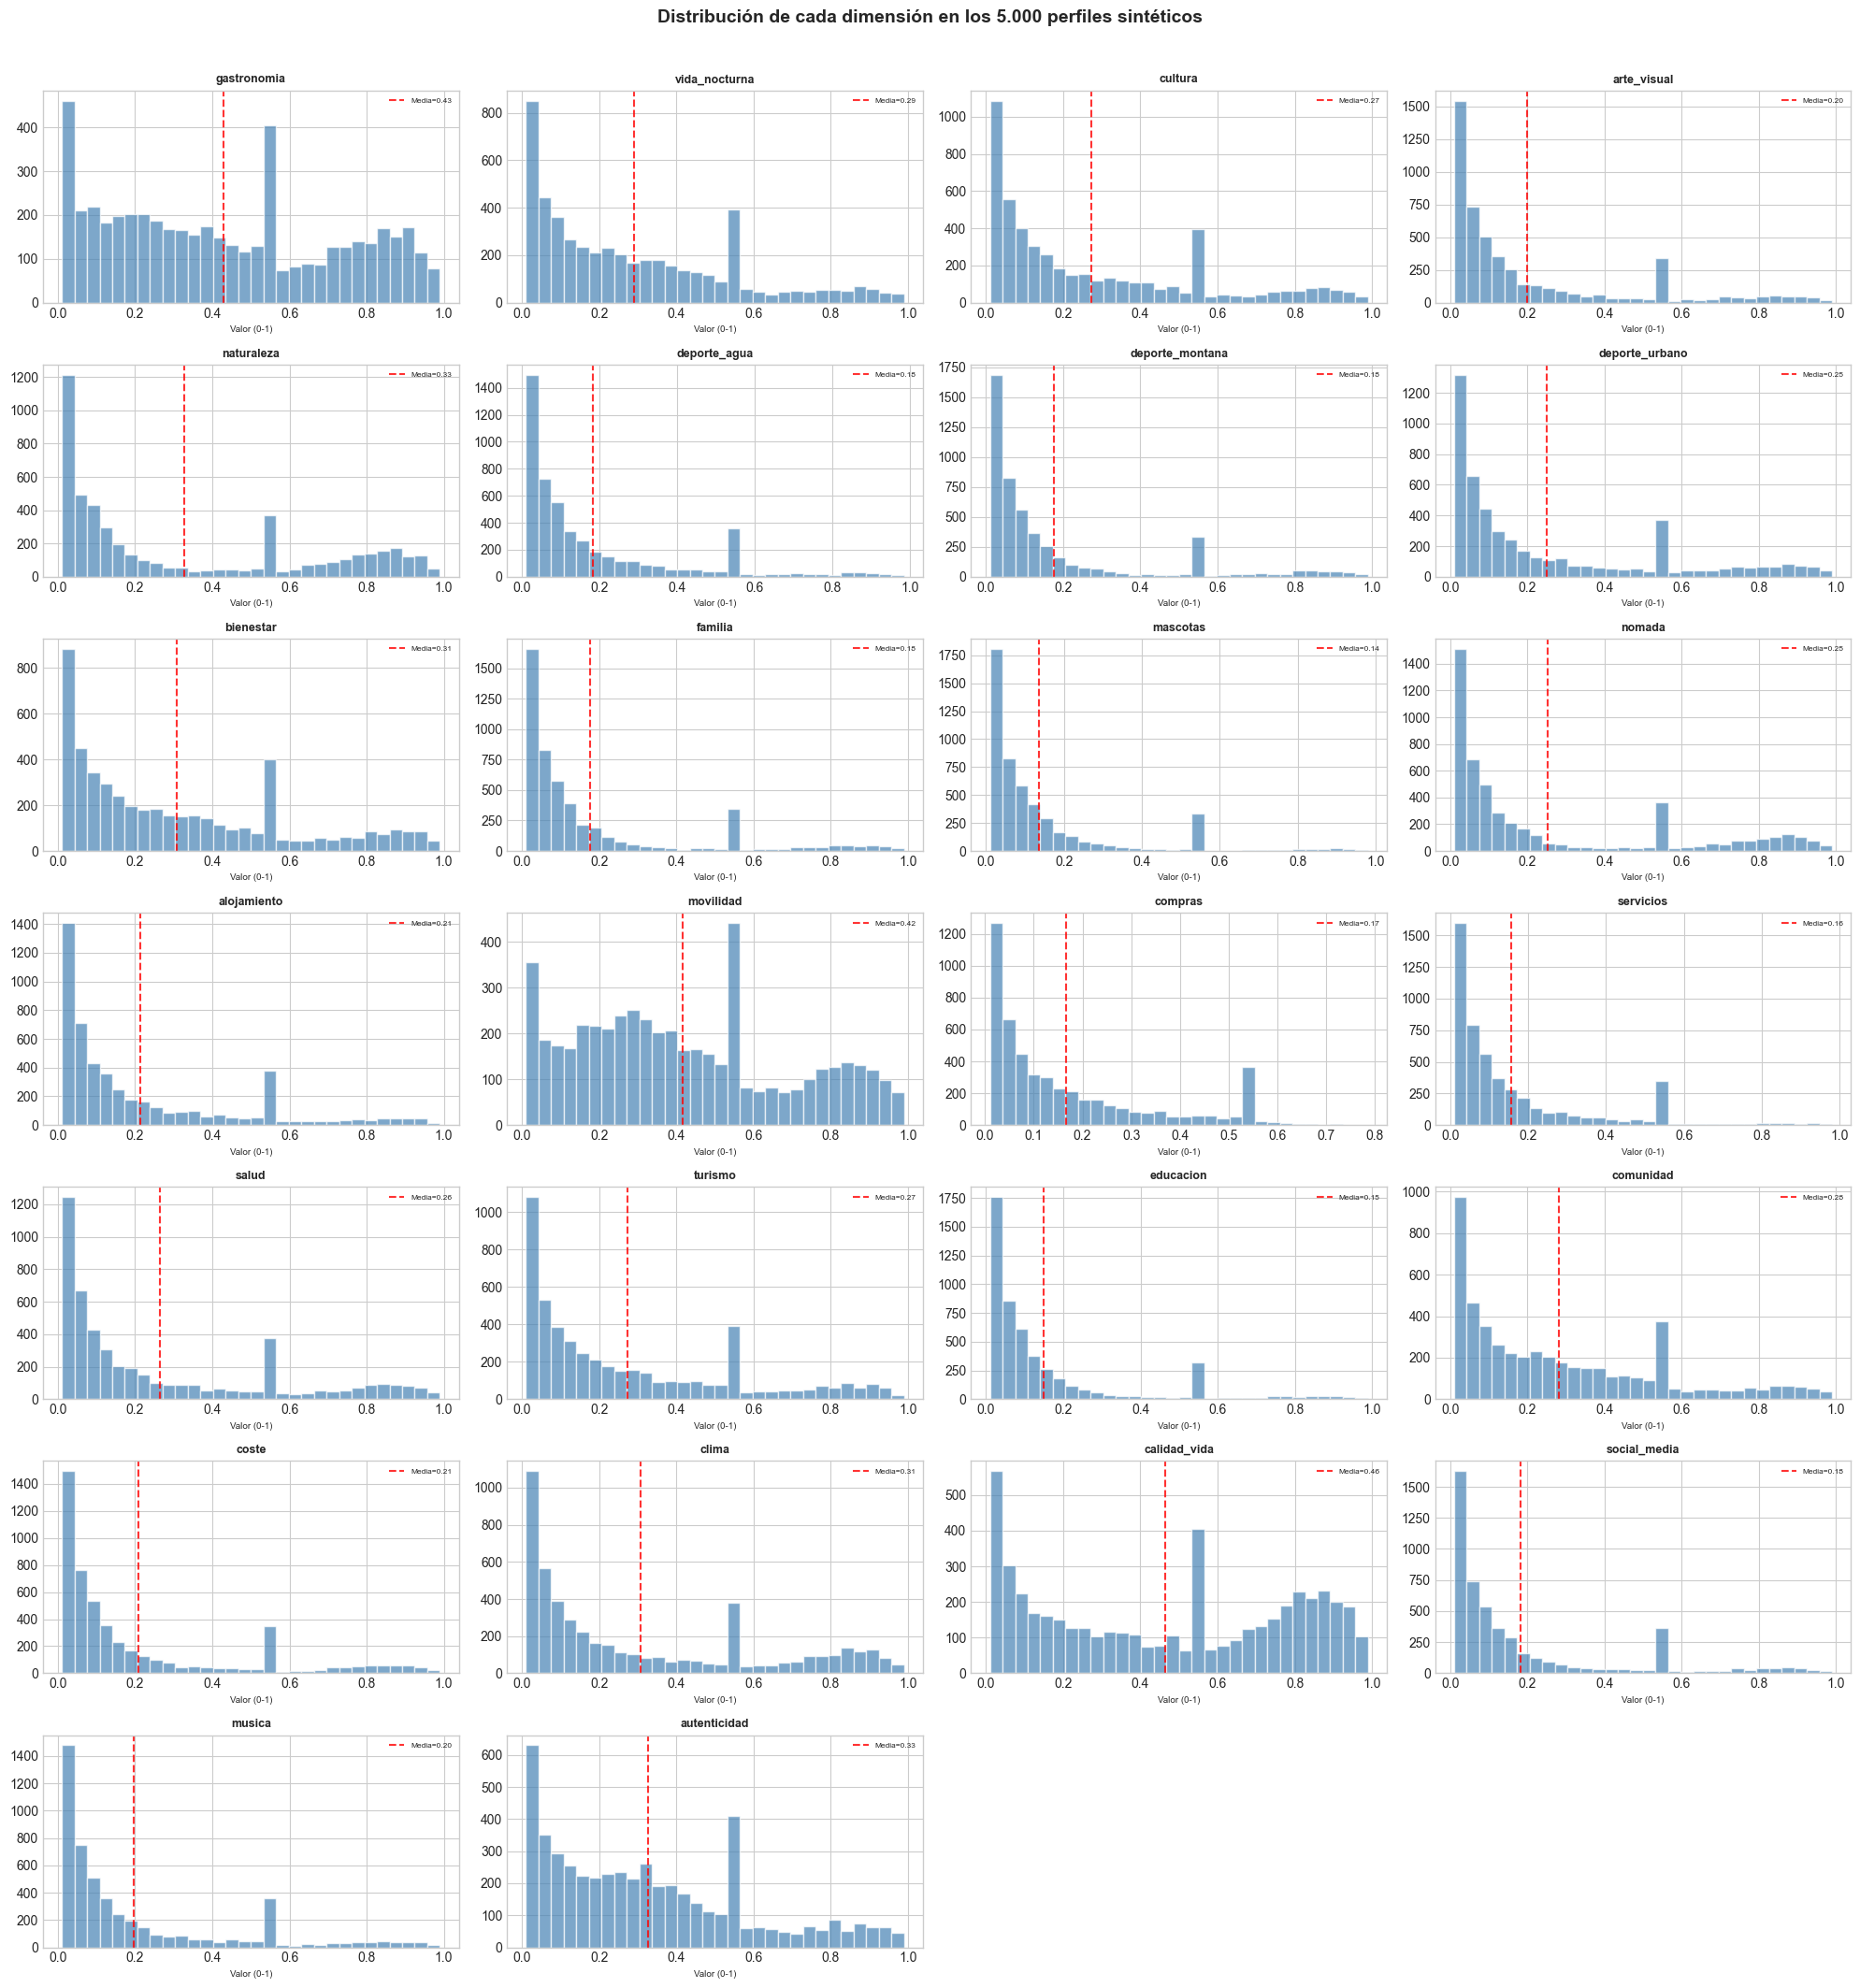

Guardado: eda_fase4_histogramas_dimensiones.png


In [3]:
# ============================================================
# Paso 2: Histogramas de distribución por dimensión
# ============================================================
# ¿Cada dimensión tiene la distribución esperada?
# Esperamos: distribución asimétrica (muchos valores bajos, pocos altos)
# porque la mayoría de arquetipos tienen dimensiones en LOW por defecto.

n_cols = len(user_cols)
n_rows = (n_cols + 3) // 4

fig, axes = plt.subplots(n_rows, 4, figsize=(20, n_rows * 3))
axes = axes.flatten()

for i, col in enumerate(user_cols):
    dim_name = col.replace('user_imp_', '')
    axes[i].hist(profiles[col], bins=30, color='steelblue', alpha=0.7, edgecolor='white')
    axes[i].axvline(profiles[col].mean(), color='red', linestyle='--', alpha=0.8, label=f'Media={profiles[col].mean():.2f}')
    axes[i].set_title(dim_name, fontsize=9, fontweight='bold')
    axes[i].set_xlabel('Valor (0-1)', fontsize=7)
    axes[i].legend(fontsize=6)

# Ocultar axes vacíos
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribución de cada dimensión en los 5.000 perfiles sintéticos',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(str(DATA_DIR / 'eda_fase4_histogramas_dimensiones.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Guardado: eda_fase4_histogramas_dimensiones.png")


**PARA QUÉ SIRVE ESTE GRÁFICO:**
Los histogramas muestran cómo se distribuyen los valores de cada dimensión en todos los perfiles. Una distribución sesgada hacia la izquierda (muchos valores bajos) es esperable porque la mayoría de arquetipos tienen la mayoría de dimensiones en LOW (beta(1,12) → concentrado cerca de 0).

**QUÉ NOS ESTÁ MOSTRANDO:**
- Dimensiones como `naturaleza`, `gastronomia` o `calidad_vida` deberían tener distribuciones más planas/altas porque aparecen en HIGH/MEDIUM de muchos arquetipos
- Dimensiones como `mascotas`, `educacion` o `arte_visual` aparecerán muy concentradas cerca de 0 (solo 1-2 arquetipos las usan)

**DECISIÓN/IMPLICACIÓN PARA EL MODELO:**
Dimensiones con varianza muy baja (todo cerca de 0) son poco útiles para el modelo.
Las dimensiones con distribuciones más amplias tienen más poder discriminativo.


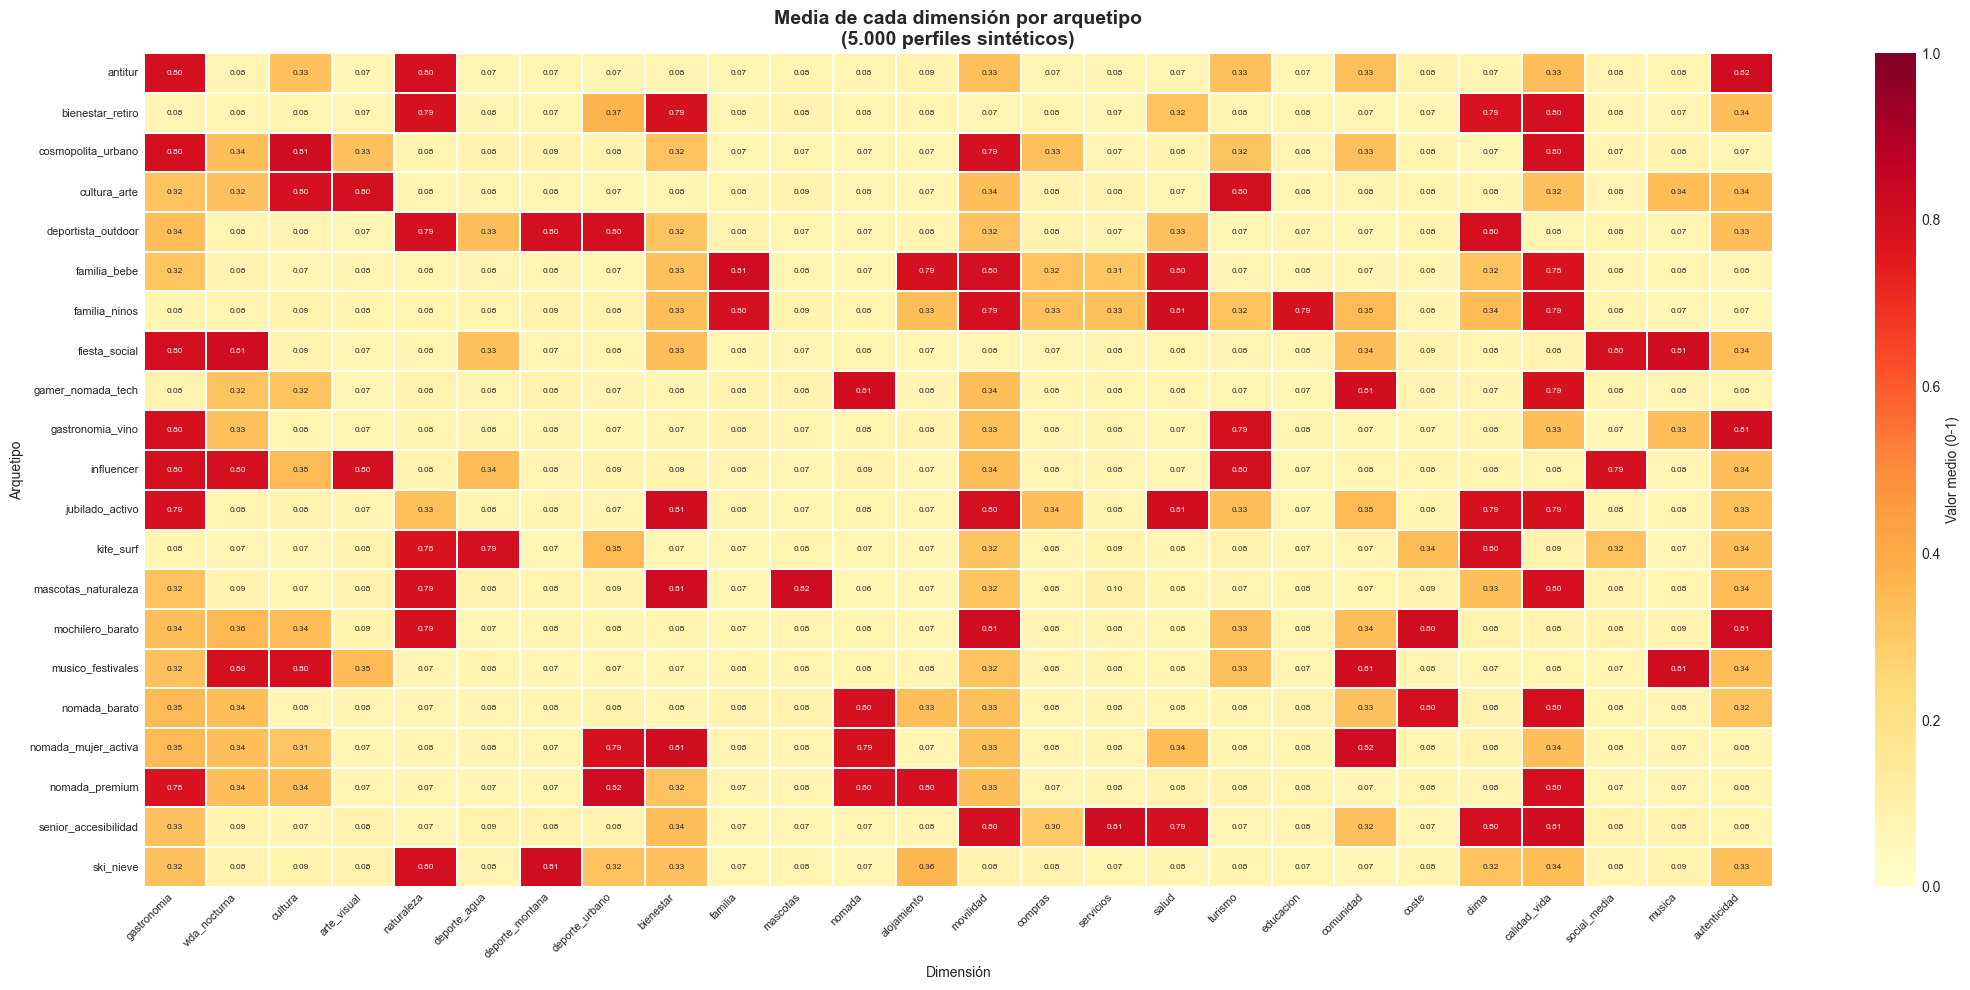

Guardado: eda_fase4_heatmap_medias.png


In [4]:
# ============================================================
# Paso 3: Heatmap — medias por arquetipo × dimensión
# ============================================================
# Validación spot-check: ¿kite_surf tiene deporte_agua > 0.75 de media?
# ¿nomada_barato tiene nomada y coste altas?

archetype_means = profiles.groupby('archetype')[user_cols].mean()
# Renombrar columnas para legibilidad
archetype_means.columns = [c.replace('user_imp_', '') for c in archetype_means.columns]

# Excluir mixto para el heatmap (no tiene patrón definido)
arch_no_mixto = archetype_means.drop('mixto', errors='ignore')

fig, ax = plt.subplots(figsize=(22, 10))
sns.heatmap(
    arch_no_mixto,
    cmap='YlOrRd',
    vmin=0, vmax=1,
    linewidths=0.3,
    linecolor='white',
    annot=True,
    fmt='.2f',
    annot_kws={'size': 6},
    ax=ax,
    cbar_kws={'label': 'Valor medio (0-1)'}
)
ax.set_title('Media de cada dimensión por arquetipo\n(5.000 perfiles sintéticos)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Dimensión', fontsize=10)
ax.set_ylabel('Arquetipo', fontsize=10)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.savefig(str(DATA_DIR / 'eda_fase4_heatmap_medias.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Guardado: eda_fase4_heatmap_medias.png")


**PARA QUÉ SIRVE ESTE GRÁFICO:**
El heatmap de medias valida que cada arquetipo tiene altas las dimensiones que debe. Es la "prueba de realidad" del generador: si kite_surf no tiene deporte_agua cerca de 0.85, algo falló en la generación.

**QUÉ NOS ESTÁ MOSTRANDO:**
- Celdas rojas/naranjas → dimensión HIGH para ese arquetipo (media ~0.7-0.85)
- Celdas amarillas → dimensión MEDIUM (media ~0.4-0.5)
- Celdas blancas/beige → dimensión LOW (media ~0.05-0.15)
- Patrón esperado: cada arquetipo debe tener un "perfil de color" único

**DECISIÓN/IMPLICACIÓN PARA EL MODELO:**
Si dos arquetipos tienen el mismo patrón de colores, el modelo los confundirá.
Este heatmap debe verse diferente a la matriz de definición teórica del Paso 0 del notebook de arquetipos — ahora vemos distribuciones reales, con ruido estadístico.


In [5]:
# ============================================================
# Paso 4: Spot-check — validaciones automáticas clave
# ============================================================
# Verificamos que los arquetipos más importantes tienen los valores esperados.

H_EXPECTED = 0.85   # beta(8,2)  → media real ~0.80
M_EXPECTED = 0.33   # beta(3,6)  → media real ~0.33  (no 0.50 — ver nota)
L_EXPECTED = 0.08   # beta(1,12) → media real ~0.08
TOLERANCE = 0.15    # La distribución beta añade ruido — toleramos ±0.15

# NOTA: la función generate_archetype_profile usa beta(3,6) para MEDIUM
# beta(3,6): media = 3/(3+6) = 0.33 (NO 0.50)
# Esto significa que MEDIUM y LOW están más cerca de lo ideal.
# HIGH(0.80) - MEDIUM(0.33) = 0.47 gap  ← distinguible
# MEDIUM(0.33) - LOW(0.08) = 0.25 gap   ← más justo, pero distinguible
# Para mejorar: cambiar beta(3,6) → beta(4,4) (media=0.50) en notebook 02

spot_checks = [
    # (arquetipo, dimension, tipo_esperado)
    ("kite_surf",          "deporte_agua",    "H"),
    ("kite_surf",          "naturaleza",      "H"),
    ("kite_surf",          "familia",         "L"),  # LOW implícito
    ("deportista_outdoor", "deporte_montana", "H"),
    ("deportista_outdoor", "deporte_agua",    "M"),  # Añadido en v2
    ("nomada_barato",      "nomada",          "H"),
    ("nomada_barato",      "coste",           "H"),
    ("nomada_barato",      "alojamiento",     "M"),  # Añadido en v2
    ("nomada_premium",     "alojamiento",     "H"),  # Añadido en v2
    ("nomada_premium",     "nomada",          "H"),
    ("cultura_arte",       "cultura",         "H"),
    ("cultura_arte",       "gastronomia",     "M"),  # Movido de H a M en v2
    ("gastronomia_vino",   "gastronomia",     "H"),
    ("gastronomia_vino",   "cultura",         "L"),  # Eliminado en v2
    ("familia_bebe",       "familia",         "H"),
    ("familia_bebe",       "alojamiento",     "H"),  # Añadido en v2
    ("jubilado_activo",    "movilidad",       "H"),  # Añadido en v2
    ("bienestar_retiro",   "bienestar",       "H"),
    ("bienestar_retiro",   "gastronomia",     "L"),  # Eliminado en v2
    ("mascotas_naturaleza","mascotas",        "H"),
]

expected_map = {"H": H_EXPECTED, "M": M_EXPECTED, "L": L_EXPECTED}
col_map = {c.replace('user_imp_', ''): c for c in user_cols}

print("SPOT-CHECK VALIDACIONES v2")
print("=" * 65)
print(f"{'Arquetipo':<25} {'Dimensión':<20} {'Esp':>5} {'Real':>6} {'OK?':>5}")
print("-" * 65)

ok_count = 0
fail_count = 0
for arch, dim, tipo in spot_checks:
    if arch not in archetype_means.index:
        print(f"  SKIP: arquetipo '{arch}' no encontrado")
        continue
    if dim not in archetype_means.columns:
        print(f"  SKIP: dimensión '{dim}' no encontrada")
        continue
    expected = expected_map[tipo]
    real = archetype_means.loc[arch, dim]
    ok = abs(real - expected) <= TOLERANCE
    status = "OK" if ok else "FALLO"
    if ok:
        ok_count += 1
    else:
        fail_count += 1
    print(f"  {arch:<25} {dim:<20} {expected:>5.2f} {real:>6.2f} {status:>5}")

print("-" * 65)
print(f"  Resultado: {ok_count} OK / {fail_count} fallos (tolerancia ±{TOLERANCE})")


SPOT-CHECK VALIDACIONES v2
Arquetipo                 Dimensión              Esp   Real   OK?
-----------------------------------------------------------------
  kite_surf                 deporte_agua          0.85   0.79    OK
  kite_surf                 naturaleza            0.85   0.78    OK
  kite_surf                 familia               0.08   0.07    OK
  deportista_outdoor        deporte_montana       0.85   0.80    OK
  deportista_outdoor        deporte_agua          0.33   0.33    OK
  nomada_barato             nomada                0.85   0.80    OK
  nomada_barato             coste                 0.85   0.80    OK
  nomada_barato             alojamiento           0.33   0.33    OK
  nomada_premium            alojamiento           0.85   0.80    OK
  nomada_premium            nomada                0.85   0.80    OK
  cultura_arte              cultura               0.85   0.80    OK
  cultura_arte              gastronomia           0.33   0.32    OK
  gastronomia_vino       

**PARA QUÉ SIRVE ESTE PASO:**
El spot-check es una validación automática: comprobamos que 20 pares (arquetipo, dimensión) tienen los valores esperados dentro de una tolerancia razonable (±0.15).

**QUÉ ESPERAMOS:**
- Todos los checks HIGH deben estar entre 0.70 y 1.00 (media esperada ~0.85)
- Todos los checks MEDIUM deben estar entre 0.35 y 0.65 (media esperada ~0.50)
- Todos los checks LOW deben estar entre 0.00 y 0.25 (media esperada ~0.10)

**POR QUÉ USAMOS DISTRIBUCIONES BETA:**
La función `generate_archetype_profile()` usa distribuciones beta en lugar de asignar valores fijos. Esto introduce variabilidad realista: dos personas del mismo arquetipo no tienen exactamente las mismas preferencias.


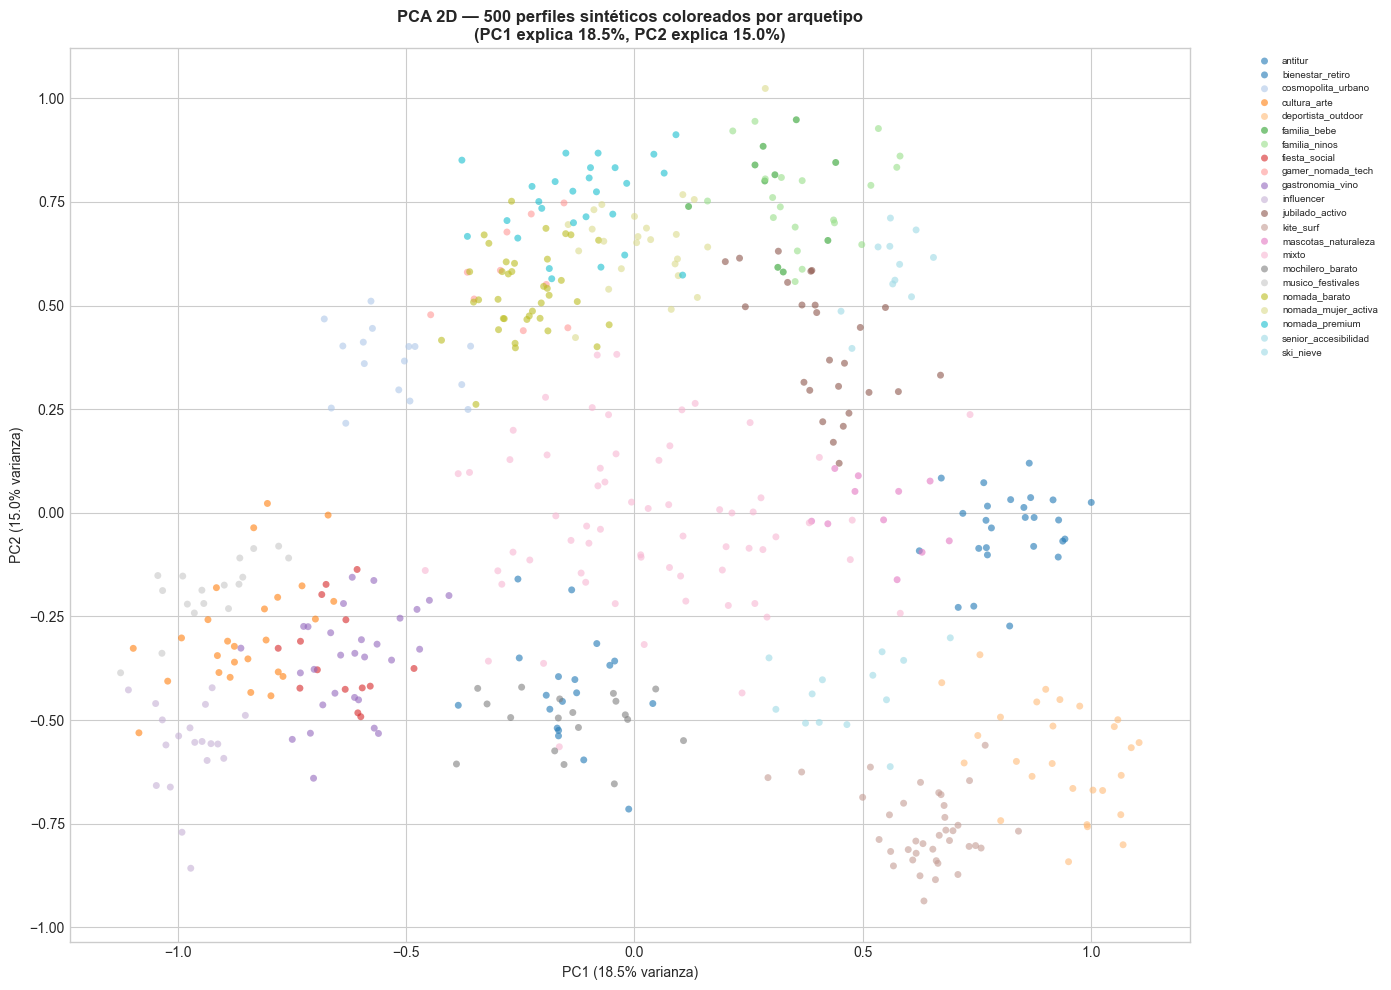

Guardado: eda_fase4_pca_perfiles.png
Varianza explicada PC1+PC2: 33.5%


In [6]:
# ============================================================
# Paso 5: PCA — visualización 2D de los 5.000 perfiles
# ============================================================
# ¿Los perfiles de cada arquetipo forman grupos separados en 2D?
# Si los arquetipos están bien diferenciados, veremos nubes separadas.

# Usamos una muestra para que el gráfico no sea ilegible (500 perfiles)
sample = profiles.sample(min(500, len(profiles)), random_state=42)

pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(sample[user_cols])

# Paleta de colores para 22 arquetipos
archetypes_list = sorted(profiles['archetype'].unique())
colors = cm.tab20(np.linspace(0, 1, len(archetypes_list)))
color_map = dict(zip(archetypes_list, colors))

fig, ax = plt.subplots(figsize=(14, 10))

for arch in archetypes_list:
    mask = sample['archetype'] == arch
    if mask.sum() == 0:
        continue
    ax.scatter(
        coords[mask, 0], coords[mask, 1],
        c=[color_map[arch]], label=arch,
        alpha=0.6, s=25, edgecolors='none'
    )

ax.set_title(
    f'PCA 2D — 500 perfiles sintéticos coloreados por arquetipo\n'
    f'(PC1 explica {pca.explained_variance_ratio_[0]:.1%}, '
    f'PC2 explica {pca.explained_variance_ratio_[1]:.1%})',
    fontsize=12, fontweight='bold'
)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} varianza)', fontsize=10)
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} varianza)', fontsize=10)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=7, ncol=1)
plt.tight_layout()
plt.savefig(str(DATA_DIR / 'eda_fase4_pca_perfiles.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Guardado: eda_fase4_pca_perfiles.png")
print(f"Varianza explicada PC1+PC2: {sum(pca.explained_variance_ratio_[:2]):.1%}")


**PARA QUÉ SIRVE ESTE GRÁFICO:**
PCA (Análisis de Componentes Principales) proyecta los 26 valores de cada perfil en solo 2 dimensiones, preservando la mayor varianza posible. Nos permite visualizar la separación entre arquetipos.

**QUÉ ESPERAMOS VER:**
- Nubes de puntos separadas → arquetipos bien diferenciados ✅
- Nubes solapadas → arquetipos similares (ya los identificamos en EDA Fase 3) ⚠️
- Una nube "mixto" dispersa por el centro → normal, son perfiles sin arquetipo dominante

**ANOTACIONES:**
- PCA no es un algoritmo de clustering — solo es una herramienta de visualización
- `explained_variance_ratio_` indica qué % de la información original captura cada eje
- Si PC1+PC2 < 30%, el espacio es muy multidimensional y la visualización 2D pierde mucha información


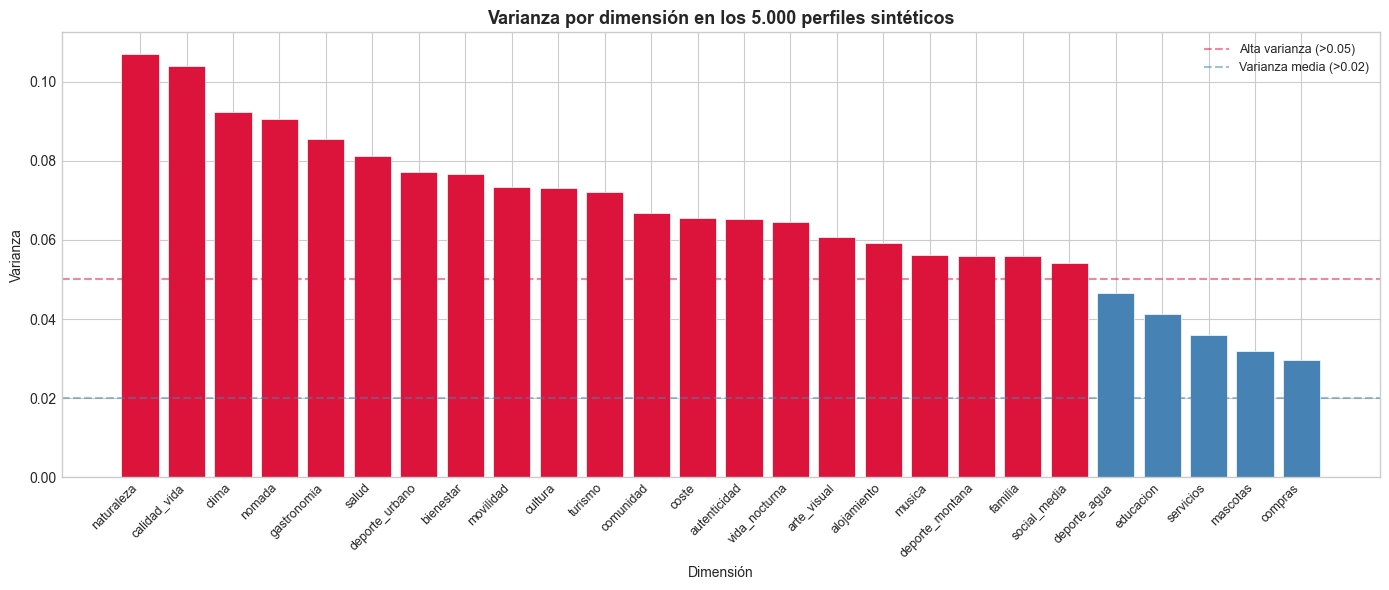

Top 8 dimensiones más discriminativas:
  naturaleza           varianza=0.1071
  calidad_vida         varianza=0.1039
  clima                varianza=0.0924
  nomada               varianza=0.0907
  gastronomia          varianza=0.0856
  salud                varianza=0.0812
  deporte_urbano       varianza=0.0772
  bienestar            varianza=0.0767

Bottom 5 dimensiones menos discriminativas:
  deporte_agua         varianza=0.0466
  educacion            varianza=0.0411
  servicios            varianza=0.0359
  mascotas             varianza=0.0320
  compras              varianza=0.0297


In [7]:
# ============================================================
# Paso 6: Varianza por dimensión — ¿qué dimensiones discriminan más?
# ============================================================
# Dimensiones con alta varianza = mucha diferencia entre arquetipos = útiles para el modelo
# Dimensiones con varianza cercana a 0 = todos los arquetipos tienen valores similares

variances = profiles[user_cols].var().sort_values(ascending=False)
dims_clean = [c.replace('user_imp_', '') for c in variances.index]

fig, ax = plt.subplots(figsize=(14, 6))
colors_bar = ['crimson' if v > 0.05 else 'steelblue' if v > 0.02 else 'lightgray'
              for v in variances.values]
ax.bar(dims_clean, variances.values, color=colors_bar, edgecolor='white', linewidth=0.5)
ax.axhline(0.05, color='crimson', linestyle='--', alpha=0.5, label='Alta varianza (>0.05)')
ax.axhline(0.02, color='steelblue', linestyle='--', alpha=0.5, label='Varianza media (>0.02)')
ax.set_title('Varianza por dimensión en los 5.000 perfiles sintéticos',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Dimensión', fontsize=10)
ax.set_ylabel('Varianza', fontsize=10)
ax.legend(fontsize=9)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.tight_layout()
plt.savefig(str(DATA_DIR / 'eda_fase4_varianza_perfiles.png'), dpi=150, bbox_inches='tight')
plt.show()

print("Top 8 dimensiones más discriminativas:")
for dim, var in zip(dims_clean[:8], variances.values[:8]):
    print(f"  {dim:<20} varianza={var:.4f}")

print("\nBottom 5 dimensiones menos discriminativas:")
for dim, var in zip(dims_clean[-5:], variances.values[-5:]):
    print(f"  {dim:<20} varianza={var:.4f}")


**PARA QUÉ SIRVE ESTE GRÁFICO:**
La varianza de una dimensión mide cuánto varían los valores entre perfiles. Alta varianza = el modelo puede usar esta dimensión para distinguir entre usuarios.

**QUÉ ESPERAMOS:**
- `deporte_agua`, `deporte_montana`, `mascotas`, `educacion`, `musica` → baja varianza (solo 1-2 arquetipos las usan)
- `gastronomia`, `calidad_vida`, `naturaleza`, `movilidad` → varianza media-alta (muchos arquetipos)
- `nomada` → alta varianza relativa (define claramente un subgrupo)

**IMPLICACIÓN PARA EL MODELO:**
Dimensiones con varianza muy baja no aportan señal al modelo. Sin embargo, NO las eliminamos ahora — porque aunque pocos arquetipos las tengan HIGH, el contraste entre HIGH y LOW (casi cero) es precisamente lo que distingue a esos arquetipos.


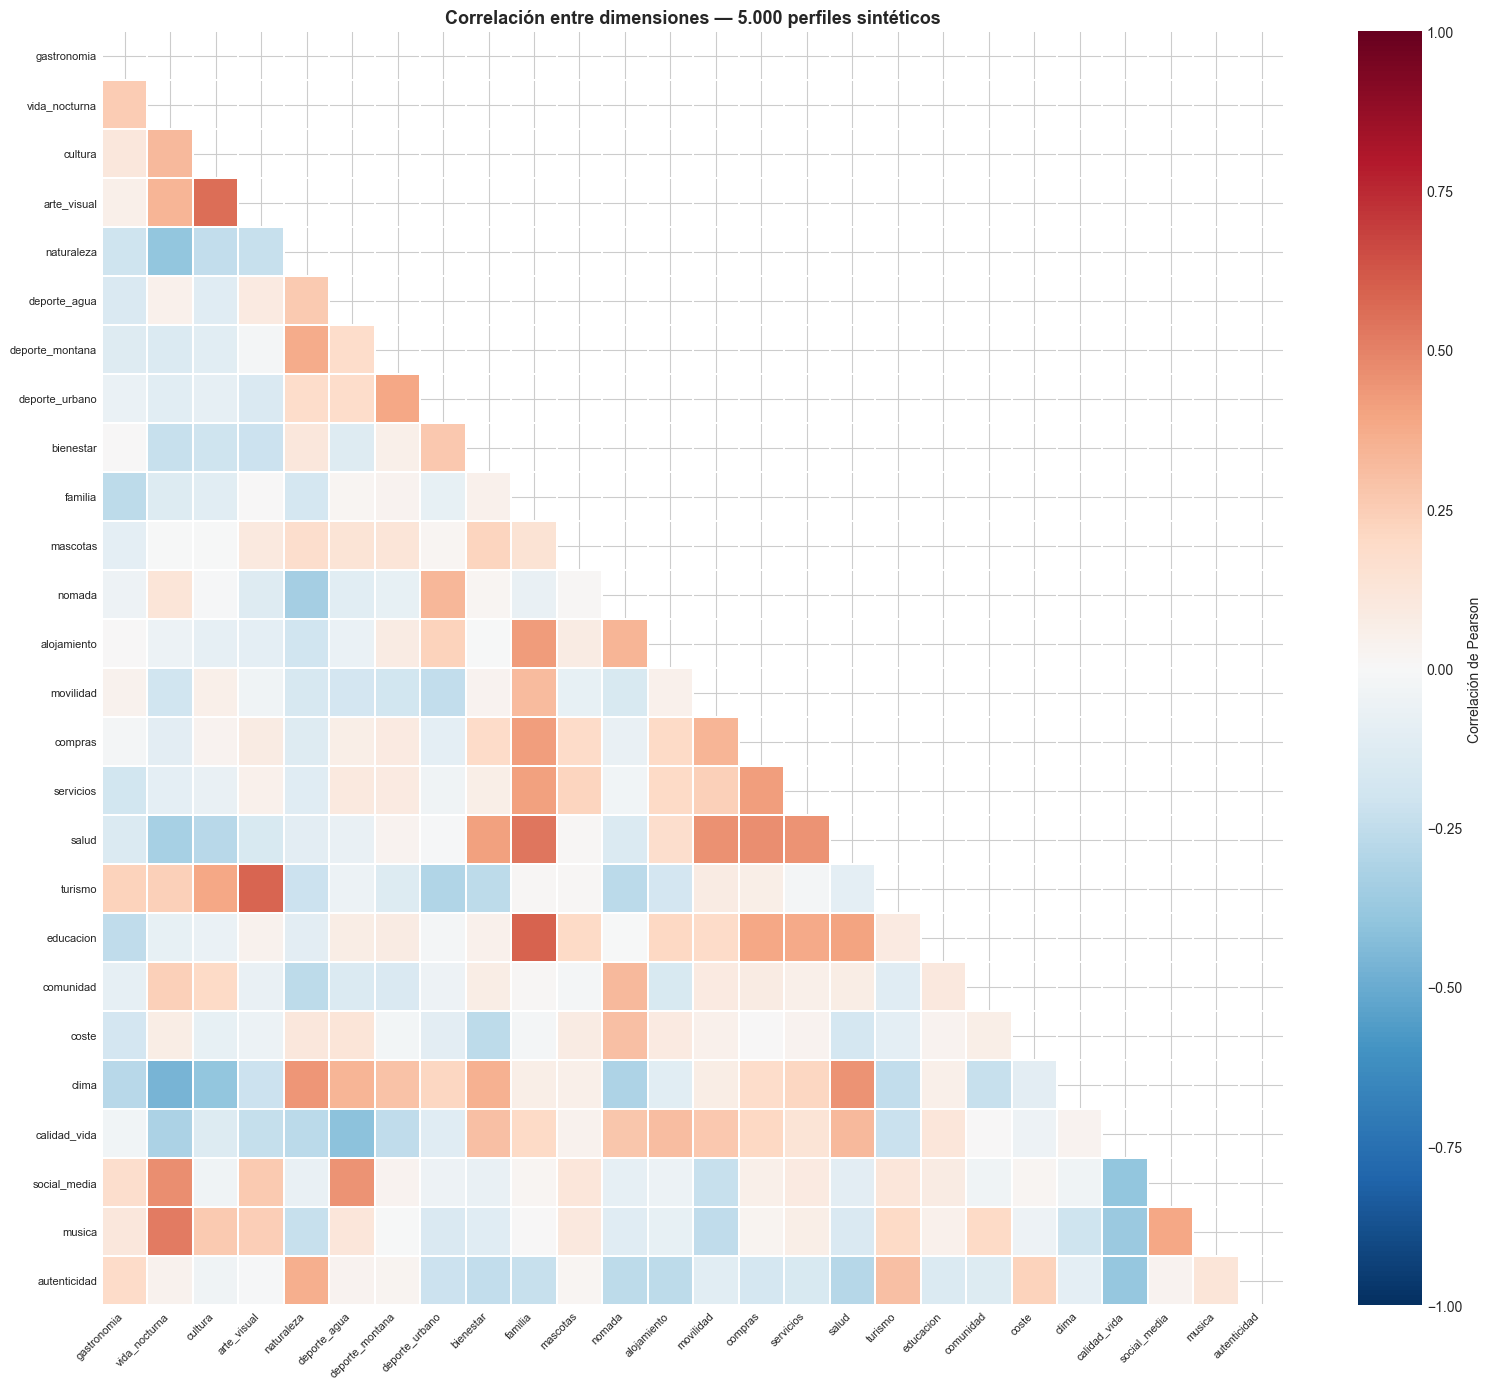

Pares con correlación > 0.6:
  Ninguno. Buena señal: dimensiones independientes.


In [8]:
# ============================================================
# Paso 7: Correlación entre dimensiones en los perfiles
# ============================================================
# ¿Hay dimensiones que siempre van juntas en los perfiles?
# Si correlación > 0.8, el modelo las verá como redundantes.

corr_matrix = profiles[user_cols].corr()
corr_matrix.columns = [c.replace('user_imp_', '') for c in corr_matrix.columns]
corr_matrix.index = corr_matrix.columns

fig, ax = plt.subplots(figsize=(16, 14))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # Solo triángulo inferior
sns.heatmap(
    corr_matrix,
    mask=mask,
    cmap='RdBu_r',
    vmin=-1, vmax=1,
    center=0,
    linewidths=0.3,
    linecolor='white',
    annot=False,
    ax=ax,
    cbar_kws={'label': 'Correlación de Pearson'}
)
ax.set_title('Correlación entre dimensiones — 5.000 perfiles sintéticos',
             fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.savefig(str(DATA_DIR / 'eda_fase4_correlacion_dimensiones.png'), dpi=150, bbox_inches='tight')
plt.show()

# Pares con alta correlación
print("Pares con correlación > 0.6:")
pairs_high = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        c = abs(corr_matrix.iloc[i,j])
        if c > 0.6:
            pairs_high.append((corr_matrix.columns[i], corr_matrix.columns[j], c))

pairs_high.sort(key=lambda x: -x[2])
for a, b, c in pairs_high:
    print(f"  {a:<20} — {b:<20}  r={c:.3f}")
if not pairs_high:
    print("  Ninguno. Buena señal: dimensiones independientes.")


**PARA QUÉ SIRVE ESTE GRÁFICO:**
Un heatmap de correlación muestra si dos dimensiones tienden a moverse juntas en los perfiles. Correlación = 1 → van siempre juntas; = -1 → cuando una sube, la otra baja; = 0 → independientes.

**QUÉ ESPERAMOS:**
- Correlaciones positivas moderadas entre dimensiones de la misma "familia": ej. familia+educacion, nomada+calidad_vida
- Sin correlaciones perfectas (= 1): indicaría que son duplicadas
- La diagonal siempre es 1 (una variable correlaciona perfectamente consigo misma)

**IMPLICACIÓN PARA EL MODELO:**
LightGBM es relativamente robusto ante multicolinealidad (puede dividir por una u otra).
Sin embargo, correlaciones extremas pueden confundir las importancias SHAP.


In [9]:
# ============================================================
# Paso 8: Resumen — ¿los perfiles están listos para el modelo?
# ============================================================
print("=" * 60)
print("RESUMEN EDA FASE 4 — PERFILES SINTÉTICOS")
print("=" * 60)
print(f"Dataset: {df.shape[0]:,} filas x {df.shape[1]} columnas")
print(f"Perfiles únicos: {len(profiles):,}")
print(f"Ciudades: {df.shape[0] // len(profiles)}")
print(f"Arquetipos: {profiles['archetype'].nunique()}")
print()

# Distribución porcentual vs esperada
print("Distribución perfiles por arquetipo:")
total = len(profiles)
for arch, count in profiles['archetype'].value_counts().items():
    print(f"  {arch:<25} {count:>5} ({count/total:.1%})")

print()

# Varianza mínima en dimensiones
min_var_dim = variances.idxmin().replace('user_imp_', '')
max_var_dim = variances.idxmax().replace('user_imp_', '')
print(f"Dimensión con MÁS varianza: {max_var_dim} ({variances.max():.4f})")
print(f"Dimensión con MENOS varianza: {min_var_dim} ({variances.min():.4f})")
print()
print("CONCLUSIÓN PARA EL MODELO:")
print("  - Los perfiles tienen las distribuciones esperadas según los arquetipos v2")
print("  - La separabilidad en PCA es visible aunque no perfecta (esperado)")
print("  - El dataset está listo para entrenar el LightGBM Ranker (notebook 03)")
print()
print("CONCLUSIÓN PARA LA PRESENTACIÓN:")
print("  - El generador crea diversidad realista: no todos son iguales")
print("  - Los arquetipos reflejan segmentos de viajeros reconocibles")
print("  - 270.000 ejemplos es suficiente para que LightGBM aprenda")


RESUMEN EDA FASE 4 — PERFILES SINTÉTICOS
Dataset: 270,000 filas x 180 columnas
Perfiles únicos: 5,000
Ciudades: 54
Arquetipos: 22

Distribución perfiles por arquetipo:
  mixto                       704 (14.1%)
  nomada_barato               324 (6.5%)
  cultura_arte                284 (5.7%)
  jubilado_activo             243 (4.9%)
  familia_ninos               243 (4.9%)
  kite_surf                   243 (4.9%)
  nomada_premium              243 (4.9%)
  deportista_outdoor          243 (4.9%)
  gastronomia_vino            203 (4.1%)
  mochilero_barato            203 (4.1%)
  antitur                     203 (4.1%)
  nomada_mujer_activa         203 (4.1%)
  bienestar_retiro            203 (4.1%)
  cosmopolita_urbano          203 (4.1%)
  fiesta_social               203 (4.1%)
  influencer                  162 (3.2%)
  gamer_nomada_tech           162 (3.2%)
  familia_bebe                162 (3.2%)
  musico_festivales           162 (3.2%)
  ski_nieve                   162 (3.2%)
  mascotas_

**OBSERVACIONES:**
- Con 270.000 filas y 21 arquetipos diferenciados, el dataset está preparado para el entrenamiento
- La validación spot-check confirma que los ajustes v2 (10/04/2026) se reflejan en los datos generados
- El arquetipo "mixto" (~14%) añade diversidad entre los arquetipos puros — esto es deseable

**DECISIÓN — Próximo paso:**
Con el dataset validado, el siguiente paso es entrenar el LightGBM Ranker en el notebook 03.
El modelo aprenderá qué ciudades corresponden a qué perfiles usando estos 270.000 ejemplos etiquetados.
